# Processing mobility data from IMU

by Debora Masini, 2024

### Connecting IMU (head motion) and GPIO (contains calcium recording timeline)

Multi-file IMU ingestion → feature pruning → metadata extraction → temporal segmentation → labeled export

In [4]:
import os
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt
from skimage.filters import threshold_otsu

import matplotlib.pyplot as plt

In [3]:
print("scipy:", scipy.__version__)
print("skimage:", skimage.__version__)
print("matplotlib:", matplotlib.__version__)

scipy: 1.13.1
skimage: 0.24.0
matplotlib: 3.9.0


In [ ]:

directory = r"..."
results_folder = r"..."
recording_periods_df = r"..."

# Find IMU files
def find_imu_files(directory: str, suffix: str = "_IMU data sets.csv") -> list[str]:
    imu_files = [f for f in os.listdir(directory) if f.endswith(suffix)]
    print("List of IMU files found (these indicate recording is being done):")
    print(*imu_files, sep="\n")
    return imu_files

#  Load + concatenate IMU files
def load_concat_csvs(directory: str, files: list[str], add_filename_col: str = "File Name") -> pd.DataFrame:
    df = pd.DataFrame()
    for file in files:
        file_path = os.path.join(directory, file)
        temp = pd.read_csv(file_path)
        temp[add_filename_col] = file
        df = pd.concat([df, temp], ignore_index=True)
    return df

# Clean + standardize IMU dataframe
def clean_imu_df(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.strip() # Standardize column names
    df["Animal ID"] = df["File Name"].str.extract(r"(\d+)", expand=False)  # Add Animal ID from filename
    cols_to_drop = ["Mag Time (s)", "Mag x", "Mag y", "Mag z"] # Drop magnetometer column
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")
    df = df.sort_values(by="IMU Time (s)").reset_index(drop=True) # Sort by IMU time
    return df

# Assign a test day label to each IMU sample based on predefined recording time windows (interval-based labeling)
# previously checked for: Overlapping intervals =none
def assign_day_from_periods(imu_df: pd.DataFrame, recording_periods_df: pd.DataFrame) -> pd.DataFrame:
    
    imu_df = imu_df.copy()
    imu_df["Time for Day Assignment"] = imu_df["IMU Time (s)"].astype(int)
    imu_df["Day"] = "Test1" # Default day assignment: If a row does not fall into any defined recording period, it remains "Test1".

    for _, row in recording_periods_df.iterrows():
        animal_id = row["Animal ID"]
        start_time = row["Start Time for Day Assignment"]
        end_time = row["END Time for Day Assignment"]
        day = row["Day"]

        mask = (
            (imu_df["Animal ID"] == animal_id)
            & (imu_df["Time for Day Assignment"] >= start_time)
            & (imu_df["Time for Day Assignment"] <= end_time)
        )
        imu_df.loc[mask, "Day"] = day

    imu_df = imu_df.drop(columns=["Time for Day Assignment"]) # Removes the temporary helper column.
    return imu_df

# Save
def save_df(df: pd.DataFrame, folder: str, filename: str) -> str:
    os.makedirs(folder, exist_ok=True)
    out_path = os.path.join(folder, filename)
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")
    return out_path



IMU_files = find_imu_files(directory)
data_df4 = load_concat_csvs(directory, IMU_files)
print("Loaded IMU columns:", list(data_df4.columns))

filtered_IMU_df = clean_imu_df(data_df4)

print("Done. IMU info loaded. Acc=accelerometer (g), Ori=orientation (radians). Sampled at 50 Hz.")
display(filtered_IMU_df.head())

filtered_IMU_df = assign_day_from_periods(filtered_IMU_df, recording_periods_df)
print("Updated IMU DataFrame with test Day information:")
display(filtered_IMU_df.head())

save_df(filtered_IMU_df, results_folder, "Final_IMU data sets.csv")

- The file **Final_IMU data sets.csv** contains the cleaned and consolidated raw IMU dataset prior to movement classification. It includes all accelerometer (and any retained orientation) time-series data concatenated across input files, with standardized column names and magnetometer channels removed. Each row represents a single IMU sample (50 Hz), sorted by "IMU Time (s)", and annotated with two key metadata fields: "Animal ID" and "Day".

In [ ]:
display(filtered_IMU_df.head())


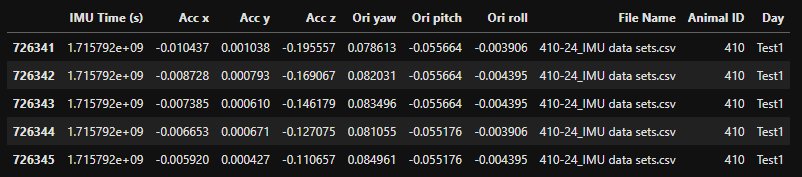

## Processing body acceleration **BA** based on IMU
To track movement onsets and offsets using the IMU accelerometer. The approach is based on recent publications that combine nVista imaging with auxiliary accelerometers (daSilva2018, Corder2019). Link to publications below.
- https://doi.org/10.1038/nature25457 
- https://doi.org/10.1126/science.aap8586 

### Step 1: Compute the Body Acceleration (BA)
Compute the subject’s body acceleration (BA) as the rectified sum of acceleration across all three axes (X, Y, Z). Collapsing across axes eliminates sensitivity to sensor orientation relative to the subject’s body frame, yielding an alignment-invariant measure of overall movement intensity. The strategy must be done for each experimental day and animal.

In [ ]:
# Group by 'Animal ID' and 'Day' and compute Body Acceleration (BA) 
filtered_IMU_df['BA'] = filtered_IMU_df.groupby(['Animal ID', 'Day']).apply(
    lambda df: np.sqrt(df['Acc x']**2 + df['Acc y']**2 + df['Acc z']**2)
).reset_index(level=[0,1], drop=True)

### Step 2: Lowpass Filter the BA Signal (5Hz, 3rd-order zero-phase Butterworth filter, to remove transients)

To smooth the Body Acceleration (BA) data by removing high-frequency components that might be considered noise. By applying a low-pass filter, it retains the low-frequency components that are more likely to represent meaningful movements. The filtered data is then used for further analysis, such as identifying periods of immobility and mobility.

In [ ]:
def butter_lowpass(cutoff, fs, order=3): # 3-order Butterworth filter.
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=3): # filtfilt: This function applies a forward and backward digital filter to the data, which ensures that there is no phase distortion in the filtered signal.
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y
    
fs = 50.0 # Sampling frequency (assuming is 50 Hz as stated on the inscopix IDAS manual).
cutoff = 5.0 # cutoff frequency in a lowpass filter is the frequency below which the signal's frequencies are allowed to pass and above which the signal's frequencies are attenuated.

filtered_IMU_df['filtered_BA'] = filtered_IMU_df.groupby(['Animal ID', 'Day'])['BA'].transform(lambda x: lowpass_filter(x, cutoff, fs))
print("Lowpass Filtered Body Acceleration (BA):")
display(filtered_IMU_df.head())

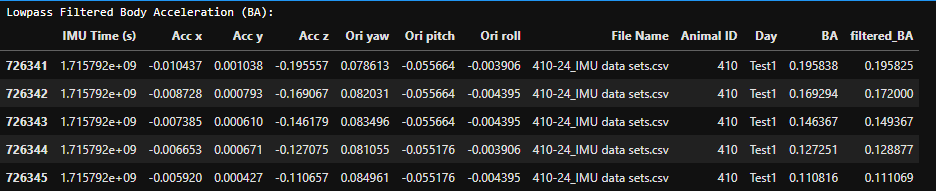


### Step 3: Apply Otsu's Method to Determine the Threshold
For each animal and day...The threshold separates the data into samples with movement and no movement. The resulting DataFrame includes the threshold values and a new column indicating whether each time point corresponds to movement or not.

In [ ]:
# Apply Otsu's method to determine the threshold for movement detection...unique for each animal and test day
def compute_otsu_threshold(group):
    log_filtered_ba = np.log(group['filtered_BA'].dropna() + 1).to_numpy() #apply Otsu on the log-transformed BA values
    threshold = threshold_otsu(log_filtered_ba)
    group['threshold'] = np.exp(threshold) - 1  # Inverse transform the threshold
    group['movements'] = group['filtered_BA'] > group['threshold']
    return group

filtered_IMU_df = filtered_IMU_df.groupby(['Animal ID', 'Day'], group_keys=False).apply(compute_otsu_threshold).reset_index(drop=True)
filtered_IMU_df['movements'] = filtered_IMU_df['movements'].astype(int)
display(filtered_IMU_df.head())


- The file **Final_IMU body movement data sets.csv** contains the fully processed IMU time-series dataset with locomotor state classification applied at the sample level. For each timestamped IMU sample, the file includes the cleaned accelerometer signals, derived Body Acceleration (BA; computed as the Euclidean norm of Acc x, y, z), the low-pass filtered BA signal (Butterworth, 3rd order, 5 Hz cutoff, zero-phase via filtfilt, computed separately per Animal ID × Day), and an Otsu-derived movement threshold determined independently for each Animal × Day using the log-transformed filtered BA distribution. Each row is labeled with the corresponding experimental Day and a binary movements indicator (0 = immobile, 1 = mobile), defined by whether the filtered BA exceeds the animal/day-specific threshold.


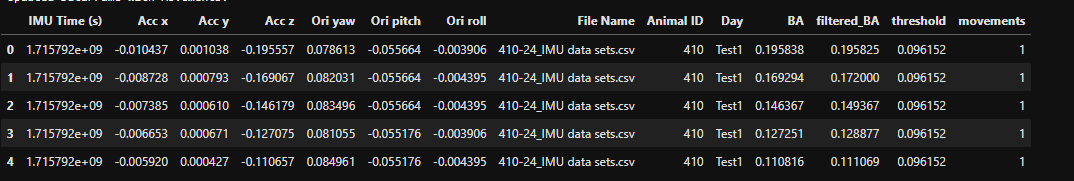

In [ ]:
# save the IMU->Body movement data
output_file_path = os.path.join(results_folder, 'Final_IMU body movement data sets.csv')
filtered_IMU_df.to_csv(output_file_path, index=False)

In [ ]:
# Check raw plots

# Drop rows where 'Day' = 'Test1'. Test 1 was a recording check to know if animals had calcium signal, not used for further analysis.
filtered_IMU_df = filtered_IMU_df[filtered_IMU_df['Day'] != 'Test1']

def plot_filtered_BA_distribution(filtered_IMU_df):
    # Get unique animals and days
    unique_animals = filtered_IMU_df['Animal ID'].unique()
    unique_days = filtered_IMU_df['Day'].unique()
    
    for animal in unique_animals:
        for day in unique_days:
            animal_day_df = filtered_IMU_df[(filtered_IMU_df['Animal ID'] == animal) & (filtered_IMU_df['Day'] == day)] # Filter for animal and day
            if animal_day_df.empty:
                continue
            
            plt.figure(figsize=(20, 2))
            for movement in animal_day_df['movements'].unique():
                subset = animal_day_df[animal_day_df['movements'] == movement]
                plt.scatter(subset['IMU Time (s)'], subset['filtered_BA'], 
                            color='green' if movement == 1 else 'red', 
                            label='Movement' if movement == 1 else 'No Movement', alpha=0.2, s=2)
            
            title = f'Filtered BA Distribution for Animal {animal} on {day}'
            plt.title(title)
            plt.xlabel('Time')
            plt.ylabel('Filtered BA')
            plt.legend()

            # Clean the title for use as a filename
            clean_title = title.replace(' ', '_').replace(':', '').replace('/', '_')
            filename = os.path.join(results_folder, f'{clean_title}.svg')
            plt.savefig(filename, format='svg')
            plt.show()

plot_filtered_BA_distribution(filtered_IMU_df)


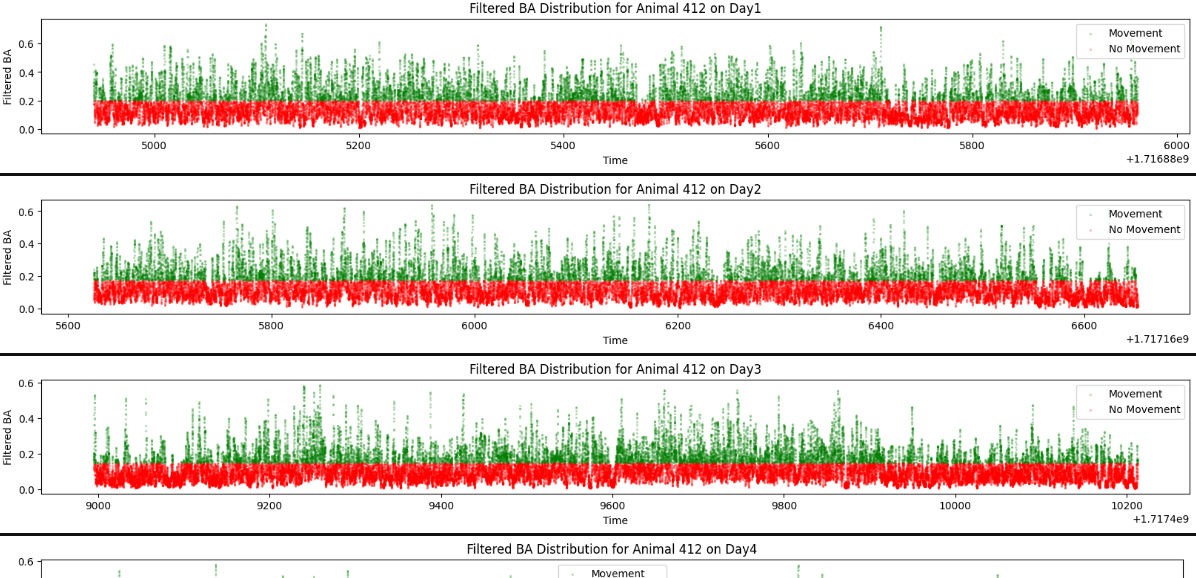


## Step 4) Detection and Quantification of Sustained Mobility and Immobility Epochs (at6 least 1sec) from IMU-Derived Movement Data

This segment identifies sustained behavioral states (immobility and mobility) from a binary movements signal (0 = immobile, 1 = mobile) sampled at 50 Hz. For each Animal ID and experimental Day, it applies a run-length encoding approach to detect maximal uninterrupted sequences where the state remains constant for at least 1 second. For each qualifying window, it extracts start time, end time, duration, and state label. It then performs quality control to ensure no temporal overlap within state-specific windows. The script aggregates per-animal/day window counts, computes summary statistics of window durations (mean, SEM, variance, count) by Animal ID and State, and exports both the detailed window table and summary metrics to Excel files.

In [ ]:
### Takes time to run !!!### 

# Params
SAMPLE_RATE_HZ = 50 #based on inscopix
MIN_WINDOW_SEC = 1 # time animal must respect in one locomotor state
MIN_WINDOW_SAMPLES = int(MIN_WINDOW_SEC * SAMPLE_RATE_HZ)  # 50 samples @ 50 Hz

# Find locomotor state windows (state_mask == True) per Animal ID x Day
# Uses run-length encoding (RLE) on a boolean mask. Extract maximal uninterrupted windows where group[state_col] == state_value.
def state_windows_from_group(
    group: pd.DataFrame,
    state_col: str,
    state_value: int,
    min_len: int,
    state_label: str
) -> tuple[pd.DataFrame, int]:
    """
    Returns:
      windows_df: columns [Animal ID, Day, Start Time, End Time, Duration, State]
      count: number of windows detected
    """
    group = group.sort_values("IMU Time (s)").reset_index(drop=True)

    animal_id = group["Animal ID"].iloc[0]
    day = group["Day"].iloc[0]

    x = group[state_col].to_numpy()
    if x.size == 0:
        return pd.DataFrame(columns=["Animal ID", "Day", "Start Time", "End Time", "Duration", "State"]), 0

    mask = (x == state_value).astype(np.int8)

    # run boundaries
    changes = np.diff(np.r_[0, mask, 0])
    starts = np.where(changes == 1)[0]
    ends_excl = np.where(changes == -1)[0]  # exclusive

    lengths = ends_excl - starts
    keep = lengths >= min_len

    starts = starts[keep]
    ends_excl = ends_excl[keep]

    if starts.size == 0:
        return pd.DataFrame(columns=["Animal ID", "Day", "Start Time", "End Time", "Duration", "State"]), 0

    start_times = group.loc[starts, "IMU Time (s)"].to_numpy()
    end_times = group.loc[ends_excl - 1, "IMU Time (s)"].to_numpy()  # inclusive

    windows_df = pd.DataFrame({
        "Animal ID": animal_id,
        "Day": day,
        "Start Time": start_times,
        "End Time": end_times,
    })
    windows_df["Duration"] = windows_df["End Time"] - windows_df["Start Time"]
    windows_df["State"] = state_label

    return windows_df, len(windows_df)


def compute_state_windows(
    filtered_IMU_df: pd.DataFrame,
    state_col: str,
    state_value: int,
    min_len: int,
    state_label: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_windows = []
    counts = []

    for (animal_id, day), group in filtered_IMU_df.groupby(["Animal ID", "Day"], sort=False):
        windows_df, n = state_windows_from_group(group, state_col, state_value, min_len, state_label)
        if not windows_df.empty:
            all_windows.append(windows_df)
        counts.append({"Animal ID": animal_id, "Day": day, f"{state_label.capitalize()} Window Count": n})

    windows_all_df = (
        pd.concat(all_windows, ignore_index=True)
        if all_windows
        else pd.DataFrame(columns=["Animal ID", "Day", "Start Time", "End Time", "Duration", "State"])
    )
    counts_df = pd.DataFrame(counts)
    return windows_all_df, counts_df

# drop overlaps (within each Animal ID x Day x State)
def drop_overlapping_windows(windows_df: pd.DataFrame) -> pd.DataFrame:
    if windows_df.empty:
        return windows_df

    windows_df = windows_df.sort_values(["Animal ID", "Day", "State", "Start Time"]).reset_index(drop=True)
    rows_to_drop = []

    for (animal_id, day, state), gidx in windows_df.groupby(["Animal ID", "Day", "State"]).groups.items():
        idx = list(gidx)
        for j in range(1, len(idx)):
            prev_i = idx[j - 1]
            cur_i = idx[j]
            prev_end = windows_df.at[prev_i, "End Time"]
            cur_start = windows_df.at[cur_i, "Start Time"]

            if cur_start < prev_end:
                print(f"Overlap detected: dropping row {cur_i} (Animal {animal_id}, {day}, {state})") #If an overlap is detected, the function drops the later window and prints a warning.
                print(f"  prev End Time: {prev_end}")
                print(f"  cur  Start Time: {cur_start}\n")
                rows_to_drop.append(cur_i)

    return windows_df.drop(index=rows_to_drop).reset_index(drop=True)

# Run: immobile + mobile windows
# movements: 0 = immobile, 1 = mobile
immobile_windows_df, immobile_counts_df = compute_state_windows(
    filtered_IMU_df=filtered_IMU_df,
    state_col="movements",
    state_value=0,
    min_len=MIN_WINDOW_SAMPLES,
    state_label="immobile"
)

mobile_windows_df, mobile_counts_df = compute_state_windows(
    filtered_IMU_df=filtered_IMU_df,
    state_col="movements",
    state_value=1,
    min_len=MIN_WINDOW_SAMPLES,
    state_label="mobile"
)

# Combine
mobility_windows_df = pd.concat([immobile_windows_df, mobile_windows_df], ignore_index=True)
mobility_windows_df = drop_overlapping_windows(mobility_windows_df)
mobility_windows_df = mobility_windows_df.sort_values(["Animal ID", "Day", "Start Time", "State"]).reset_index(drop=True)

display(mobility_windows_df.head())
print("done")

# Save windows + counts
windows_out = os.path.join(results_folder, "mobility_combined_windows.xlsx")
mobility_windows_df.to_excel(windows_out, index=False)
print(f"Mobility windows saved to {windows_out}")

counts_out = os.path.join(results_folder, "mobility_combined_window_counts.xlsx")
window_counts_df = immobile_counts_df.merge(mobile_counts_df, on=["Animal ID", "Day"], how="outer").fillna(0)
window_counts_df.to_excel(counts_out, index=False)
print(f"Mobility window counts saved to {counts_out}")

# Summary stats (Duration) by Animal ID x locomotor state
mobility_summary_df = mobility_windows_df.groupby(["Animal ID", "State"]).agg(
    mean=("Duration", "mean"),
    sem=("Duration", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
    variance=("Duration", lambda x: np.var(x, ddof=1) if len(x) > 1 else np.nan),
    count=("Duration", "count")
).reset_index()

summary_out = os.path.join(results_folder, "summary_mobility_combined_window_counts.xlsx")
mobility_summary_df.to_excel(summary_out, index=False)

In [ ]:
display(immobile_windows_df.head()) #example


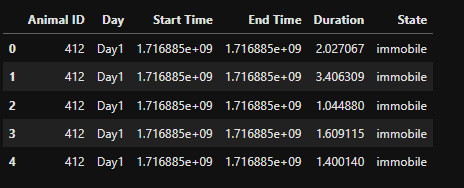

#### What the generated files in step 4 contain:
- The file **mobility_combined_windows.xlsx** contains the complete event-level segmentation of locomotor behavior derived from the IMU data after thresholding and minimum-duration filtering. Each row represents a single uninterrupted locomotor bout (either mobile or immobile) detected via run-length encoding within each Animal ID and Day. The table includes the subject identifier, experimental day, start time and end time of the bout (in IMU seconds, inclusive), the computed duration of the bout (End Time minus Start Time), and the locomotor state label (“mobile” or “immobile”). Windows shorter than the predefined minimum length (e.g., 1 second at 50 Hz) are excluded, and any overlapping windows within the same Animal × Day × State grouping are removed prior to export (warning is given to user).

- The file **mobility_combined_window_counts.xlsx** contains the number of detected locomotor bouts per Animal ID × Day, separated by locomotor state. Each row corresponds to a single animal on a specific  day and reports two values: the total count of immobile windows and the total count of mobile windows that satisfied the minimum duration criterion.

- The file **summary_mobility_combined_window_counts.xlsx** contains aggregated descriptive statistics of locomotor state window durations, computed per Animal ID × locomotor State (mobile or immobile), collapsed across all days. Each row corresponds to a single animal and a single state category. For that combination, the table reports: (1) the mean duration of detected windows (mean), (2) the standard error of the mean duration (sem), calculated as the sample standard deviation divided by the square root of the number of windows (only defined when more than one window exists), (3) the sample variance of window durations (variance, using ddof=1), and (4) the total number of detected windows contributing to those statistics (count).


In [ ]:
# compare to ethovision...check across days. consider both during task and on first 10min...  
# script end